# 06. Decomposition + Hybrid (EWMA Trend + GRU Residual), Walk-forward + Fine-tune (lookback=7, horizon=7)

Vẫn walk-forward theo 4 khối (7,7,7,7 ngày — bỏ phần dư 1 ngày cuối để mỗi khối đều đủ 7 điểm) + fine-tune
giữa các khối như lần trước, nhưng lần này
**tách (decompose) PM2.5 thành 2 phần** trước khi đưa vào GRU, để phần "baseline dịch chuyển" được xử lý
bằng cách tính lại trực tiếp từ dữ liệu thật (không cần gradient descent) thay vì dựa vào GRU/fine-tune:

- **Trend**: `EWMA` nhân quả (`span=EWMA_SPAN=7`, chỉ dùng dữ liệu QUÁ KHỨ — `pm25.shift(1).ewm(...)`) —
  bám baseline hiện tại, tính lại tức thời khi có ngày thật mới, không cần train lại.
- **Residual = PM2.5 thực − Trend**: phần dao động còn lại sau khi trừ trend, kỳ vọng ổn định/ít bị
  distribution shift hơn nhiều so với PM2.5 gốc → GRU chỉ cần học phần này (thay hẳn cột `PM2.5` trong
  input/target bằng `Residual`).
- **Dự báo cuối cùng** = Trend tại ngày cuối cùng đã biết (giữ phẳng suốt horizon) + Residual GRU dự báo.

Train/Validate/Test và cơ chế walk-forward + fine-tune giữ nguyên như lần trước (lookback=7, horizon=7,
grid search `hidden_size x learning_rate`) — chỉ khác ở việc GRU giờ học/dự báo trên Residual thay vì
PM2.5 tuyệt đối, và MAE/RMSE cuối cùng vẫn tính trên PM2.5 thực (sau khi cộng lại Trend) để so sánh công
bằng với các lần thí nghiệm trước.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

pd.set_option('display.max_columns', None)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

WINDOW_SIZE = 28      # lookback (NGAY) - co dinh
HORIZON = 7           # horizon (NGAY) - co dinh, cung la do dai Validate
BLOCK_SIZE = HORIZON  # do dai Validate = dung bang HORIZON
TEST_BLOCKS = [7, 7, 7, 7]  # chia 28/29 ngay Test thanh 4 khoi kich thuoc = HORIZON (bo phan du 1 ngay cuoi)
EWMA_SPAN = 7         # do dai span cho EWMA trend (nhan qua, chi dung qua khu)
print(f"WINDOW_SIZE={WINDOW_SIZE} ngay, HORIZON={HORIZON} ngay, BLOCK_SIZE={BLOCK_SIZE} ngay")
print(f"TEST_BLOCKS={TEST_BLOCKS} (tong={sum(TEST_BLOCKS)} ngay), EWMA_SPAN={EWMA_SPAN}")

Device: cpu
WINDOW_SIZE=28 ngay, HORIZON=7 ngay, BLOCK_SIZE=7 ngay
TEST_BLOCKS=[7, 7, 7, 7] (tong=28 ngay), EWMA_SPAN=7


##### Bước 1: Gộp cleaned_data.csv và new_data_cleaned.csv theo ngày (chưa tách/scale)

In [2]:
df = pd.read_csv('data/cleaned_data.csv', parse_dates=['time'], index_col='time')
df = df.sort_index()

rename_mapping = {
    'pm10 (μg/m³)': 'PM10',
    'pm2_5 (μg/m³)': 'PM2.5',
    'carbon_monoxide (μg/m³)': 'Carbon Monoxide',
    'nitrogen_dioxide (μg/m³)': 'Nitrogen Dioxide',
    'sulphur_dioxide (μg/m³)': 'Sulphur Dioxide',
    'ozone (μg/m³)': 'Ozone',
    'uv_index_clear_sky ()': 'UV Index Clear Sky',
    'uv_index ()': 'UV Index',
    'dust (μg/m³)': 'Dust',
    'aerosol_optical_depth ()': 'Aerosol Optical Depth',
}
df = df.rename(columns=rename_mapping)
df = df.drop(columns=['Dust', 'UV Index', 'UV Index Clear Sky'])

pollutant_cols = ['PM10', 'PM2.5', 'Carbon Monoxide', 'Nitrogen Dioxide', 'Sulphur Dioxide', 'Ozone',
                   'Aerosol Optical Depth']
daily_hist = df[pollutant_cols].resample('D').mean()
daily_hist['month_sin'] = np.sin(2 * np.pi * daily_hist.index.month / 12)
daily_hist['month_cos'] = np.cos(2 * np.pi * daily_hist.index.month / 12)

feature_cols = daily_hist.columns.tolist()
pm25_col_idx = feature_cols.index('PM2.5')
n_features = len(feature_cols)

print(f"cleaned_data (gop ngay): {daily_hist.index.min().date()} -> {daily_hist.index.max().date()} "
      f"({len(daily_hist)} ngay)")

cleaned_data (gop ngay): 2022-08-04 -> 2026-07-26 (1453 ngay)


In [3]:
new_raw = pd.read_csv('data/new_data_cleaned.csv', parse_dates=['time'], index_col='time')
new_raw = new_raw.sort_index()
new_raw = new_raw.rename(columns=rename_mapping)
new_raw = new_raw.drop(columns=['Dust', 'UV Index', 'UV Index Clear Sky'])

daily_new = new_raw[pollutant_cols].resample('D').mean()
daily_new['month_sin'] = np.sin(2 * np.pi * daily_new.index.month / 12)
daily_new['month_cos'] = np.cos(2 * np.pi * daily_new.index.month / 12)
daily_new = daily_new[feature_cols]

print(f"new_data (gop ngay): {daily_new.index.min().date()} -> {daily_new.index.max().date()} "
      f"({len(daily_new)} ngay)")

new_data (gop ngay): 2026-07-27 -> 2026-08-24 (29 ngay)


##### Bước 2: Decomposition (EWMA Trend + Residual), rồi mới chia Train/Validate/Test và Scale

In [4]:
from sklearn.preprocessing import MinMaxScaler

# Ghep chuoi PM2.5 GOC (chua tach) lien tuc tu cleaned_data -> new_data de tinh trend nhan qua xuyen suot
pm25_full_raw = pd.concat([daily_hist['PM2.5'], daily_new['PM2.5']]).sort_index()

# Trend nhan qua: EWMA chi dung du lieu QUA KHU (shift(1) truoc khi ewm) -> khong leak ngay hien tai/tuong lai
trend_series = pm25_full_raw.shift(1).ewm(span=EWMA_SPAN, min_periods=1).mean().bfill()
residual_series = pm25_full_raw - trend_series

# Thay cot PM2.5 bang Residual - GRU se hoc/du bao Residual thay vi PM2.5 tuyet doi
daily_hist = daily_hist.copy()
daily_hist['PM2.5'] = residual_series.loc[daily_hist.index]
daily_new = daily_new.copy()
daily_new['PM2.5'] = residual_series.loc[daily_new.index]

# Validate = BLOCK_SIZE ngay cuoi cung cua cleaned_data, Train = phan con lai
train_df = daily_hist.iloc[:-BLOCK_SIZE]
val_df = daily_hist.iloc[-BLOCK_SIZE:]
print(f"Train:    {train_df.index.min().date()} -> {train_df.index.max().date()}  ({len(train_df)} ngay)")
print(f"Validate: {val_df.index.min().date()} -> {val_df.index.max().date()}  ({len(val_df)} ngay)")

# Fit scaler CHI tren Train (tren Residual, khong phai PM2.5 goc) de tranh leakage
scaler = MinMaxScaler()
train_scaled = pd.DataFrame(scaler.fit_transform(train_df), columns=feature_cols, index=train_df.index)
val_scaled = pd.DataFrame(scaler.transform(val_df), columns=feature_cols, index=val_df.index)

# Toan bo new_data (29 ngay, da thay PM2.5 -> Residual) lam Test (KHONG fit lai scaler)
test_df = daily_new.iloc[:sum(TEST_BLOCKS)]
test_scaled = pd.DataFrame(scaler.transform(test_df), columns=feature_cols, index=test_df.index)
print(f"Test: {test_scaled.index.min().date()} -> {test_scaled.index.max().date()}  ({len(test_scaled)} ngay)")
assert len(test_scaled) == sum(TEST_BLOCKS)

Train:    2022-08-04 -> 2026-07-19  (1446 ngay)
Validate: 2026-07-20 -> 2026-07-26  (7 ngay)
Test: 2026-07-27 -> 2026-08-23  (28 ngay)


##### Model & Training Utilities — Direct Multi-output GRU

In [5]:
def create_sequences(data, target_col_idx, window_size, horizon):
    """Sliding window tieu chuan, dung de tao nhieu diem goc huan luyen tu Train."""
    X, y = [], []
    for i in range(len(data) - window_size - horizon + 1):
        X.append(data[i:i + window_size])
        y.append(data[i + window_size: i + window_size + horizon, target_col_idx])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)


def make_single_origin(context_df, target_df, horizon, pm25_col_idx):
    """1 diem goc duy nhat: X = context_df (dung window_size dong), y = horizon dong DAU cua target_df."""
    X = context_df.values[np.newaxis, :, :].astype(np.float32)
    y = target_df.values[:horizon, pm25_col_idx].astype(np.float32)[np.newaxis, :]
    return X, y


class TimeSeriesDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X)
        self.y = torch.from_numpy(y)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


class MultiStepGRU(nn.Module):
    def __init__(self, input_size, horizon, hidden_size=32, num_layers=2, dropout=0.2):
        super().__init__()
        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.fc = nn.Linear(hidden_size, horizon)

    def forward(self, x):
        out, _ = self.gru(x)
        return self.fc(out[:, -1, :])


def train_model(train_scaled, X_val, y_val, pm25_col_idx, window_size, horizon, hidden_size=32,
                 num_layers=2, dropout=0.2, lr=1e-3, batch_size=64,
                 max_epochs=25, patience=5, device='cpu', verbose=False):
    X_train, y_train = create_sequences(train_scaled.values, pm25_col_idx, window_size, horizon)

    train_loader = DataLoader(TimeSeriesDataset(X_train, y_train), batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(TimeSeriesDataset(X_val, y_val), batch_size=batch_size, shuffle=False)

    model = MultiStepGRU(input_size=X_train.shape[2], horizon=horizon, hidden_size=hidden_size,
                          num_layers=num_layers, dropout=dropout).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.L1Loss()

    history = {'train_loss': [], 'val_loss': []}
    best_val_loss = float('inf')
    best_state = None
    epochs_no_improve = 0

    for epoch in range(max_epochs):
        model.train()
        train_losses = []
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            pred = model(xb)
            loss = criterion(pred, yb)
            loss.backward()
            optimizer.step()
            train_losses.append(loss.item())

        model.eval()
        val_losses = []
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                pred = model(xb)
                val_losses.append(criterion(pred, yb).item())

        train_loss = float(np.mean(train_losses))
        val_loss = float(np.mean(val_losses))
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)

        if verbose:
            print(f"  Epoch {epoch + 1}/{max_epochs} - train_loss={train_loss:.5f}, val_loss={val_loss:.5f}")

        if val_loss < best_val_loss - 1e-6:
            best_val_loss = val_loss
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                break

    model.load_state_dict(best_state)
    return model, best_val_loss, history


def inverse_transform_col(scaled_values, col_idx, scaler, n_features):
    dummy = np.zeros((len(scaled_values), n_features))
    dummy[:, col_idx] = scaled_values
    return scaler.inverse_transform(dummy)[:, col_idx]


def mae_rmse(y_true, y_pred):
    mae = np.mean(np.abs(y_true - y_pred))
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
    return mae, rmse


def fine_tune(model, extended_scaled, pm25_col_idx, window_size, horizon, lr, epochs, batch_size, device):
    """Warm-start: tiep tuc train model hien co (khong khoi tao lai) tren toan bo du lieu da biet
    (bao gom du lieu that vua quan sat), so epoch co dinh, khong early-stop (khong co validation
    "sach" de tranh leakage tu khoi Test tuong lai)."""
    X, y = create_sequences(extended_scaled.values, pm25_col_idx, window_size, horizon)
    loader = DataLoader(TimeSeriesDataset(X, y), batch_size=batch_size, shuffle=True)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.L1Loss()

    model.train()
    epoch_losses = []
    for epoch in range(epochs):
        losses = []
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            pred = model(xb)
            loss = criterion(pred, yb)
            loss.backward()
            optimizer.step()
            losses.append(loss.item())
        epoch_losses.append(float(np.mean(losses)))

    model.eval()
    return model, epoch_losses

##### Hyperparameter Tuning: Hidden Size x Learning Rate (window_size, horizon giữ cố định)

In [6]:
torch.manual_seed(42)

val_context = train_scaled.tail(WINDOW_SIZE)
X_val, y_val = make_single_origin(val_context, val_scaled, HORIZON, pm25_col_idx)

hidden_candidates = [16, 32, 64]
lr_candidates = [1e-3, 5e-4]

search_results = []
for hs in hidden_candidates:
    for lr in lr_candidates:
        print(f"Dang thu hidden_size={hs}, lr={lr}...")
        _, val_loss, _ = train_model(
            train_scaled, X_val, y_val, pm25_col_idx,
            window_size=WINDOW_SIZE, horizon=HORIZON, hidden_size=hs, lr=lr,
            max_epochs=20, patience=5, device=device,
        )
        search_results.append({'hidden_size': hs, 'lr': lr, 'val_loss': val_loss})
        print(f"  -> val_loss (MAE, thang do scaled) = {val_loss:.5f}")

search_results_df = pd.DataFrame(search_results).sort_values('val_loss').reset_index(drop=True)
search_results_df

Dang thu hidden_size=16, lr=0.001...


  -> val_loss (MAE, thang do scaled) = 0.11616
Dang thu hidden_size=16, lr=0.0005...


  -> val_loss (MAE, thang do scaled) = 0.11718
Dang thu hidden_size=32, lr=0.001...


  -> val_loss (MAE, thang do scaled) = 0.11026
Dang thu hidden_size=32, lr=0.0005...


  -> val_loss (MAE, thang do scaled) = 0.10780
Dang thu hidden_size=64, lr=0.001...


  -> val_loss (MAE, thang do scaled) = 0.09814
Dang thu hidden_size=64, lr=0.0005...


  -> val_loss (MAE, thang do scaled) = 0.11309


,hidden_size,lr,val_loss
0,64,0.0010,0.098137
1,32,0.0005,0.107800
2,32,0.0010,0.110260
3,64,0.0005,0.113086
4,16,0.0010,0.116156
5,16,0.0005,0.117182


In [7]:
# Chon cau hinh co val_loss thap nhat tuyet doi
best_row = search_results_df.sort_values('val_loss').iloc[0]

BEST_HIDDEN = int(best_row['hidden_size'])
BEST_LR = float(best_row['lr'])

print(f"Cau hinh duoc chon (val_loss thap nhat): hidden_size={BEST_HIDDEN}, lr={BEST_LR} "
      f"(val_loss={best_row['val_loss']:.5f})")

Cau hinh duoc chon (val_loss thap nhat): hidden_size=64, lr=0.001 (val_loss=0.09814)


##### Train Model cuối cùng (cấu hình tốt nhất, nhiều epoch hơn)

  Epoch 1/40 - train_loss=0.17647, val_loss=0.14872


  Epoch 2/40 - train_loss=0.09130, val_loss=0.12998


  Epoch 3/40 - train_loss=0.08679, val_loss=0.10677


  Epoch 4/40 - train_loss=0.08437, val_loss=0.11850


  Epoch 5/40 - train_loss=0.08312, val_loss=0.11676


...

  Epoch 36/40 - train_loss=0.08017, val_loss=0.09056


  Epoch 37/40 - train_loss=0.07814, val_loss=0.09000


  Epoch 38/40 - train_loss=0.07749, val_loss=0.08388


  Epoch 39/40 - train_loss=0.07642, val_loss=0.08978


  Epoch 40/40 - train_loss=0.07786, val_loss=0.09436

Best val_loss (MAE thang đo scaled, 1 điểm gốc validate) = 0.08388


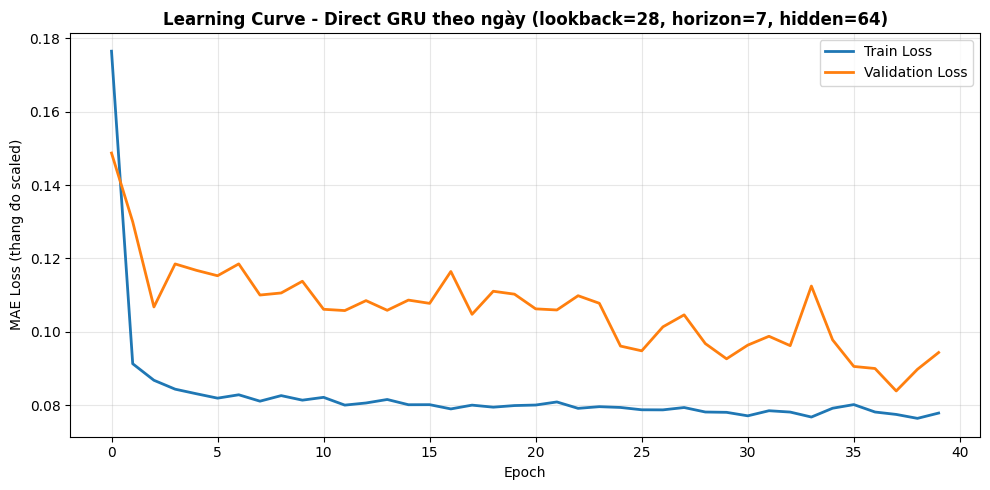

In [8]:
final_model, final_val_loss, history = train_model(
    train_scaled, X_val, y_val, pm25_col_idx,
    window_size=WINDOW_SIZE, horizon=HORIZON, hidden_size=BEST_HIDDEN, lr=BEST_LR,
    max_epochs=40, patience=8, device=device, verbose=True,
)
print(f"\nBest val_loss (MAE thang đo scaled, 1 điểm gốc validate) = {final_val_loss:.5f}")

plt.figure(figsize=(10, 5))
plt.plot(history['train_loss'], label='Train Loss', linewidth=2)
plt.plot(history['val_loss'], label='Validation Loss', linewidth=2)
plt.xlabel('Epoch'); plt.ylabel('MAE Loss (thang đo scaled)')
plt.title(f'Learning Curve - Direct GRU theo ngày (lookback={WINDOW_SIZE}, horizon={HORIZON}, hidden={BEST_HIDDEN})', fontweight='bold')
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

##### Walk-forward + Fine-tune Đánh giá trên Test (4 khối: 7, 7, 7, 7 ngày)

Sau mỗi khối (trừ khối cuối), model được **fine-tune** (warm start, lr nhỏ hơn 10 lần, epoch cố định)
trên toàn bộ dữ liệu đã biết bao gồm khối vừa quan sát, TRƯỚC KHI dự báo khối tiếp theo.

In [9]:
FT_LR = BEST_LR * 0.1
FT_EPOCHS = 5
print(f"Fine-tune: lr={FT_LR}, epochs={FT_EPOCHS}")

history_context = pd.concat([train_scaled, val_scaled]).tail(WINDOW_SIZE)  # lookback ban dau
extended_train = pd.concat([train_scaled, val_scaled])  # se mo rong dan bang du lieu that tung khoi

block_results = []
all_true, all_pred, all_times = [], [], []
start = 0

for i, block_size in enumerate(TEST_BLOCKS, start=1):
    block_target = test_scaled.iloc[start:start + block_size]

    final_model.eval()
    X = history_context.values[np.newaxis, :, :].astype(np.float32)
    with torch.no_grad():
        pred_scaled_full = final_model(torch.from_numpy(X).to(device)).cpu().numpy()[0]  # do dai = HORIZON
    pred_scaled = pred_scaled_full[:block_size]  # chi lay dung block_size gia tri dau (<= HORIZON)

    # GRU du bao RESIDUAL (khong phai PM2.5 tuyet doi) -> cong lai Trend de tai tao PM2.5 du bao
    pred_residual_block = inverse_transform_col(pred_scaled, pm25_col_idx, scaler, n_features)
    current_trend = trend_series.loc[block_target.index[0]]  # Trend tai ngay dau khoi, giu phang ca khoi
    pred_pm25_block = current_trend + pred_residual_block
    true_pm25_block = pm25_full_raw.loc[block_target.index].values  # PM2.5 THAT (thang do goc, khong qua Residual)
    mae, rmse = mae_rmse(true_pm25_block, pred_pm25_block)

    print(f"Khoi {i} ({block_target.index.min().date()} -> {block_target.index.max().date()}, "
          f"{block_size} ngay): MAE = {mae:.4f} µg/m³, RMSE = {rmse:.4f} µg/m³")

    block_results.append({'Khoi': i, 'Tu ngay': block_target.index.min().date(),
                           'Den ngay': block_target.index.max().date(), 'So ngay': block_size,
                           'MAE (µg/m³)': mae, 'RMSE (µg/m³)': rmse})
    all_true.append(true_pm25_block)
    all_pred.append(pred_pm25_block)
    all_times.append(block_target.index)

    # Cap nhat lookback: bo cac ngay cu nhat, them block THAT vua danh gia, giu dung WINDOW_SIZE ngay gan nhat
    history_context = pd.concat([history_context, block_target]).tail(WINDOW_SIZE)
    extended_train = pd.concat([extended_train, block_target])
    start += block_size

    if i < len(TEST_BLOCKS):
        final_model, ft_losses = fine_tune(
            final_model, extended_train, pm25_col_idx, WINDOW_SIZE, HORIZON,
            lr=FT_LR, epochs=FT_EPOCHS, batch_size=64, device=device,
        )
        print(f"  -> Fine-tune {FT_EPOCHS} epoch voi du lieu that Khoi {i}: "
              f"train_loss {ft_losses[0]:.5f} -> {ft_losses[-1]:.5f}")

true_pm25 = np.concatenate(all_true)
pred_pm25 = np.concatenate(all_pred)
target_times = pd.DatetimeIndex(np.concatenate(all_times))

mae_overall, rmse_overall = mae_rmse(true_pm25, pred_pm25)
print(f"\nTong hop toan bo {len(true_pm25)} ngay: MAE = {mae_overall:.4f} µg/m³, RMSE = {rmse_overall:.4f} µg/m³")

block_df = pd.DataFrame(block_results)
block_df

Fine-tune: lr=0.0001, epochs=5
Khoi 1 (2026-07-27 -> 2026-08-02, 7 ngay): MAE = 2.6422 µg/m³, RMSE = 3.3666 µg/m³


  -> Fine-tune 5 epoch voi du lieu that Khoi 1: train_loss 0.07784 -> 0.07737
Khoi 2 (2026-08-03 -> 2026-08-09, 7 ngay): MAE = 4.1494 µg/m³, RMSE = 4.9476 µg/m³


  -> Fine-tune 5 epoch voi du lieu that Khoi 2: train_loss 0.07719 -> 0.07751
Khoi 3 (2026-08-10 -> 2026-08-16, 7 ngay): MAE = 2.2170 µg/m³, RMSE = 2.5148 µg/m³


  -> Fine-tune 5 epoch voi du lieu that Khoi 3: train_loss 0.07727 -> 0.07676
Khoi 4 (2026-08-17 -> 2026-08-23, 7 ngay): MAE = 2.2983 µg/m³, RMSE = 2.5667 µg/m³

Tong hop toan bo 28 ngay: MAE = 2.8267 µg/m³, RMSE = 3.4902 µg/m³


,Khoi,Tu ngay,Den ngay,So ngay,MAE (µg/m³),RMSE (µg/m³)
0,1,2026-07-27,2026-08-02,7,2.642203,3.366633
1,2,2026-08-03,2026-08-09,7,4.149398,4.947575
2,3,2026-08-10,2026-08-16,7,2.217015,2.514823
3,4,2026-08-17,2026-08-23,7,2.298251,2.566657


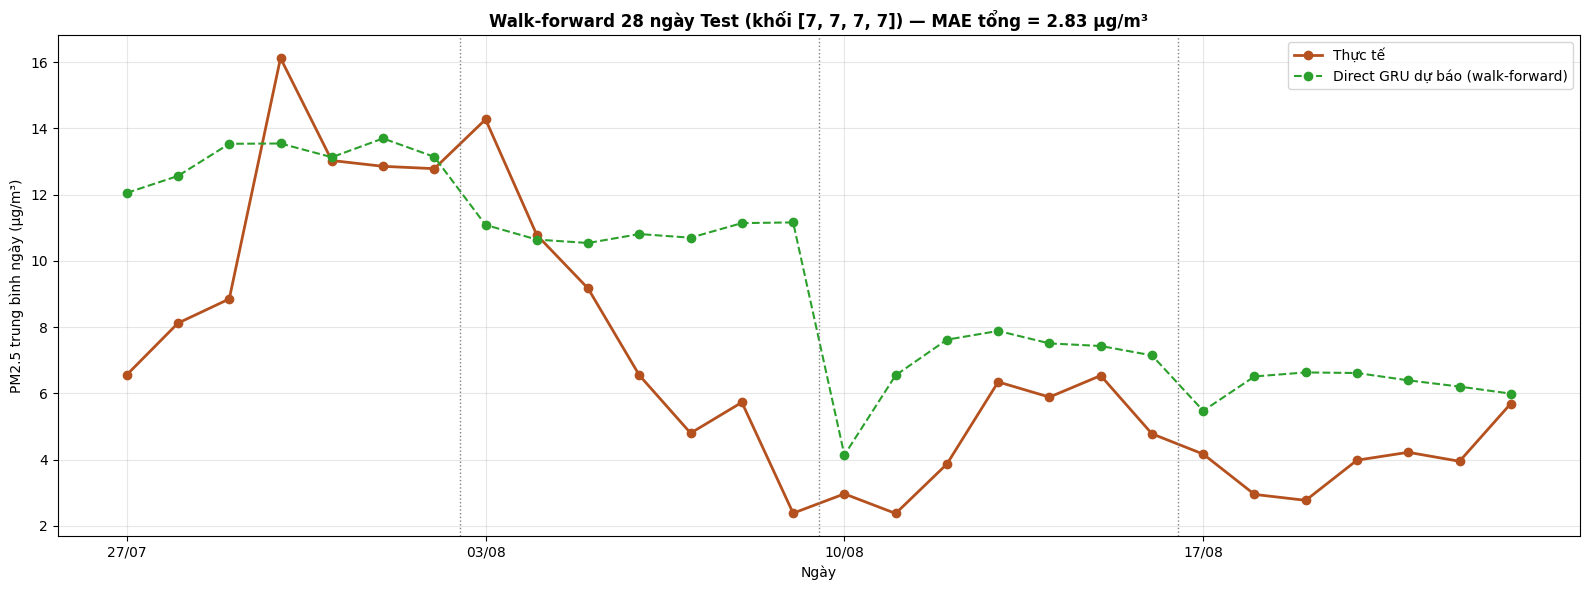

In [10]:
plt.figure(figsize=(16, 6))
plt.plot(target_times, true_pm25, label='Thực tế', color='#b4511f', linewidth=2, marker='o')
plt.plot(target_times, pred_pm25, label='Direct GRU dự báo (walk-forward)', color='#2ca02c',
         linestyle='--', linewidth=1.5, marker='o')

# Danh dau ranh gioi giua cac khoi
boundary = 0
for block_size in TEST_BLOCKS[:-1]:
    boundary += block_size
    plt.axvline(target_times[boundary - 1] + pd.Timedelta(hours=12), color='gray', linestyle=':', linewidth=1)

# Xtick dat dung tai moc bat dau moi khoi
tick_positions = []
start = 0
for block_size in TEST_BLOCKS:
    tick_positions.append(target_times[start])
    start += block_size
plt.xticks(tick_positions, [t.strftime('%d/%m') for t in tick_positions], rotation=0)

plt.xlabel('Ngày'); plt.ylabel('PM2.5 trung bình ngày (µg/m³)')
plt.title(f'Walk-forward {sum(TEST_BLOCKS)} ngày Test (khối {TEST_BLOCKS}) — MAE tổng = {mae_overall:.2f} µg/m³', fontweight='bold')
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

##### Residual Diagnostics (toàn bộ 29 ngày)

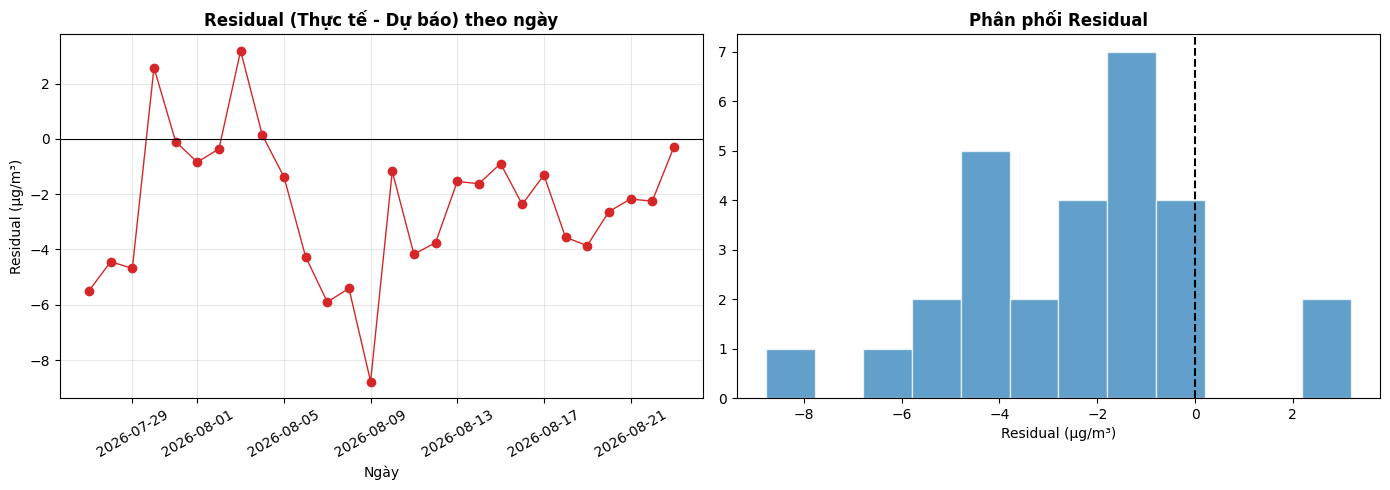

Residual mean: -2.405 µg/m³, std: 2.529 µg/m³


In [11]:
residuals = true_pm25 - pred_pm25

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(target_times, residuals, linewidth=1, color='#d62728', marker='o')
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].set_title('Residual (Thực tế - Dự báo) theo ngày', fontweight='bold')
axes[0].set_xlabel('Ngày'); axes[0].set_ylabel('Residual (µg/m³)')
axes[0].tick_params(axis='x', rotation=30)
axes[0].grid(True, alpha=0.3)

axes[1].hist(residuals, bins=12, color='#1f77b4', alpha=0.7, edgecolor='white')
axes[1].axvline(0, color='black', linestyle='--')
axes[1].set_title('Phân phối Residual', fontweight='bold')
axes[1].set_xlabel('Residual (µg/m³)')

plt.tight_layout()
plt.show()
print(f"Residual mean: {residuals.mean():.3f} µg/m³, std: {residuals.std():.3f} µg/m³")

##### Lưu Model

In [12]:
import os

os.makedirs('data/processed', exist_ok=True)
torch.save({
    'model_state_dict': final_model.state_dict(),
    'window_size': WINDOW_SIZE,
    'horizon': HORIZON,
    'hidden_size': BEST_HIDDEN,
    'num_layers': 2,
    'dropout': 0.2,
    'lr': BEST_LR,
    'granularity': 'daily',
    'eval_scheme': 'decomposition_hybrid_walk_forward_finetune',
    'ewma_span': EWMA_SPAN,
}, 'data/processed/gru_hybrid_daily_h7_lb28_decomp.pt')
print("Đã lưu model vào data/processed/gru_hybrid_daily_h7_lb28_decomp.pt")

Đã lưu model vào data/processed/gru_hybrid_daily_h7_lb28_decomp.pt


##### Nhận xét

Điền nhận xét: So với walk-forward + fine-tune KHÔNG decomposition ở lookback=7/horizon=7 (MAE tổng=3.44
µg/m³, bias=-2.96) — decomposition (EWMA Trend + GRU học Residual) có cải thiện MAE/RMSE/bias không, cải
thiện bao nhiêu? Residual (sai số dự báo, không phải Residual của decomposition) đã tiệm cận mục tiêu ±1.5
µg/m³ chưa? Trend EWMA span=7 có bám kịp xu hướng giảm PM2.5 thực tế hay vẫn còn trễ — thử span ngắn hơn
(3-5 ngày) có giúp bám nhanh hơn không?